# 05B — Single Well 1D Poroelasticity with FEniCSx — V2 Fixed

Este notebook é a versão corrigida e consolidada do primeiro modelo poroelástico 1D com FEniCSx.

## O que foi corrigido nesta versão

Esta versão já inclui:

- forma fraca compatível com kernel `DOLFINx complex`;
- uso de `ufl.conj(q)` no termo de massa;
- uso de `ufl.inner(ufl.grad(p), ufl.grad(q))` no termo difusivo;
- `petsc_options_prefix` obrigatório nas versões novas do DOLFINx;
- cache JIT dedicado em `/tmp`;
- criação garantida das colunas `step` e `time_s`;
- montagem mais robusta dos snapshots;
- fluxo mais seguro para evitar estados quebrados do Jupyter.

## Objetivo físico

Simular uma primeira poroelasticidade 1D didática:

```text
p(x,t) = pressão de poros evoluindo no tempo
u(x,t) = deslocamento associado à queda de pressão
```

O cenário é:

```text
pressão inicial uniforme
↓
queda de pressão no topo
↓
difusão de pressão
↓
resposta mecânica aproximada
↓
compactação/deformação poroelástica
```

## Entrada

```text
data/physics_ready/parquet/single_well_fenics_ready/
```

## Saída

```text
data/simulation/parquet/single_well_fenicsx_poroelasticity_1d/
```

## Observação importante

Este modelo é **semiacoplado e didático**.

Ele resolve a pressão com FEniCSx e calcula a resposta mecânica a partir da queda de pressão e do módulo de Young.

O próximo passo científico será um modelo Biot totalmente acoplado.

# STEP 0 — Environment Setup

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List, Optional
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import dolfinx
import ufl
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_PHYSICS_READY_DIR = Path("../data/physics_ready/parquet/single_well_fenics_ready")
DATA_SIMULATION_DIR = Path("../data/simulation/parquet/single_well_fenicsx_poroelasticity_1d")
REPORT_DIR = Path("../reports/single_well_fenicsx_poroelasticity_1d")

DATA_SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PHYSICS_READY_PARQUET_FILE: Optional[str] = None

# Cache JIT dedicado para evitar conflito com compilações anteriores.
JIT_CACHE_DIR = Path("/tmp/fenicsx_poroelasticity_jit_cache_v2")

# Se quiser limpar o cache toda vez que rodar, deixe True.
CLEAR_JIT_CACHE_ON_START = True

if CLEAR_JIT_CACHE_ON_START and JIT_CACHE_DIR.exists():
    shutil.rmtree(JIT_CACHE_DIR)

JIT_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("FEniCSx OK")
print("dolfinx version:", dolfinx.__version__)
print(f"DATA_PHYSICS_READY_DIR = {DATA_PHYSICS_READY_DIR.resolve()}")
print(f"DATA_SIMULATION_DIR    = {DATA_SIMULATION_DIR.resolve()}")
print(f"REPORT_DIR             = {REPORT_DIR.resolve()}")
print(f"JIT_CACHE_DIR          = {JIT_CACHE_DIR}")

FEniCSx OK
dolfinx version: 0.10.0.post2
DATA_PHYSICS_READY_DIR = /root/shared/data/physics_ready/parquet/single_well_fenics_ready
DATA_SIMULATION_DIR    = /root/shared/data/simulation/parquet/single_well_fenicsx_poroelasticity_1d
REPORT_DIR             = /root/shared/reports/single_well_fenicsx_poroelasticity_1d
JIT_CACHE_DIR          = /tmp/fenicsx_poroelasticity_jit_cache_v2


## Interpretação

Se esta célula rodou, o ambiente FEniCSx está operacional.

O cache JIT foi isolado em `/tmp` para reduzir problemas de compilação travada.

# STEP 1 — Load Physics-Ready Parquet

In [2]:
def list_parquet_files(data_dir: Path) -> List[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Pasta não encontrada: {data_dir.resolve()}")

    files = sorted(data_dir.glob("*.parquet"), key=lambda p: p.stat().st_mtime, reverse=True)

    if not files:
        raise FileNotFoundError(f"Nenhum parquet encontrado em: {data_dir.resolve()}")

    return files


def make_unique_columns(df: pd.DataFrame) -> pd.DataFrame:
    duplicated = df.columns[df.columns.duplicated()].tolist()
    if duplicated:
        print("Colunas duplicadas removidas mantendo a primeira ocorrência:")
        print(sorted(set(duplicated)))
    return df.loc[:, ~df.columns.duplicated()].copy()


physics_files = list_parquet_files(DATA_PHYSICS_READY_DIR)

display(pd.DataFrame({
    "FILE": [p.name for p in physics_files],
    "MODIFIED_TIME": [pd.Timestamp(p.stat().st_mtime, unit="s") for p in physics_files],
}))

if PHYSICS_READY_PARQUET_FILE is None:
    selected_physics_path = physics_files[0]
else:
    selected_physics_path = DATA_PHYSICS_READY_DIR / PHYSICS_READY_PARQUET_FILE
    if not selected_physics_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {selected_physics_path}")

df = pd.read_parquet(selected_physics_path)
df = make_unique_columns(df).sort_values("DEPTH").reset_index(drop=True)

if "WELL" in df.columns and df["WELL"].notna().any():
    WELL_NAME = str(df["WELL"].dropna().iloc[0])
else:
    WELL_NAME = selected_physics_path.stem.split("_fenics_ready")[0]

print(f"Arquivo selecionado: {selected_physics_path.name}")
print(f"Poço: {WELL_NAME}")
print(f"Shape: {df.shape}")
print(f"Depth min: {df['DEPTH'].min():,.3f}")
print(f"Depth max: {df['DEPTH'].max():,.3f}")

display(df.head())
display(df.tail())

,FILE,MODIFIED_TIME
0,TFT-4_fenics_ready_2350m1_2400m0.parquet,2026-05-08 14:48:38.060850382


Arquivo selecionado: TFT-4_fenics_ready_2350m1_2400m0.parquet
Poço: TFT-4
Shape: (329, 16)
Depth min: 2,350.136
Depth max: 2,399.992


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
0,TFT-4,"2,350.136400","2,409.744322","4,564.744311","2,251.323467",0.334331,"12,256,840,817.437845","33,003,964,238.271610","32,786,153,018.229519","10,988,331.988865","5,424,147.760899",0.219376,"2,350.136400","2,399.992400",0.152000,True
1,TFT-4,"2,350.288400","2,409.362810","4,515.308239","2,218.423544",0.335592,"11,913,293,372.311029","32,545,065,165.444843","31,905,485,503.589760","10,872,226.132795","5,345,663.917131",0.251638,"2,350.136400","2,399.992400",0.152000,True
2,TFT-4,"2,350.440400","2,409.240171","4,464.553345","2,188.575913",0.336538,"11,605,362,566.700142","31,991,636,763.882751","31,103,994,897.294281","10,751,782.908020","5,274,144.908529",0.286587,"2,350.136400","2,399.992400",0.152000,True
3,TFT-4,"2,350.592400","2,409.144786","4,404.476525","2,157.580660",0.337273,"11,293,693,500.715904","31,261,745,368.586189","30,277,976,074.992485","10,609,289.794359","5,200,176.422041",0.318953,"2,350.136400","2,399.992400",0.152000,True
4,TFT-4,"2,350.744400","2,408.905709","4,337.697166","2,129.403432",0.337862,"11,010,394,982.113462","30,394,247,432.326649","29,503,347,628.122078","10,446,856.563887","5,131,202.094845",0.345972,"2,350.136400","2,399.992400",0.152000,True


,WELL,DEPTH,rho_kg_m3,vp_mps,vs_mps,nu,G_pa,K_pa,E_pa,ai,si,vsh,SOURCE_DEPTH_MIN,SOURCE_DEPTH_MAX,MESH_STEP,physics_ready_valid
324,TFT-4,"2,399.384400","2,425.259936","3,417.817492","1,865.594885",0.288048,"8,461,479,016.900890","16,970,268,536.367668","21,768,744,085.145435","8,269,377.572994","4,522,558.092900",0.596667,"2,350.136400","2,399.992400",0.152000,True
325,TFT-4,"2,399.536400","2,429.335634","3,428.954997","1,871.179920",0.288117,"8,530,592,123.557176","17,114,040,401.184122","21,941,982,585.864567","8,307,618.998616","4,545,282.536272",0.596311,"2,350.136400","2,399.992400",0.152000,True
326,TFT-4,"2,399.688400","2,434.430257","3,442.876878","1,878.114600",0.288204,"8,613,100,959.222910","17,293,755,232.205284","22,156,411,146.318531","8,355,420.780645","4,572,694.585376",0.595866,"2,350.136400","2,399.992400",0.152000,True
327,TFT-4,"2,399.840400","2,437.703252","3,460.776439","1,886.508270",0.288315,"8,701,405,940.235632","17,524,817,157.804939","22,397,248,085.329918","8,414,959.192313","4,602,911.181458",0.596467,"2,350.136400","2,399.992400",0.152000,True
328,TFT-4,"2,399.992400","2,439.323485","3,484.642521","1,897.699829",0.288398,"8,818,103,024.547861","17,832,899,725.233055","22,718,364,003.972057","8,490,158.764764","4,635,465.171205",0.597377,"2,350.136400","2,399.992400",0.152000,True


## Interpretação

Carregamos a camada `physics-ready`.

Ela contém os campos físicos preparados para simulação.

Neste notebook o campo mais importante é:

```text
E_pa
```

Ele controla a deformação associada à queda de pressão.

# STEP 2 — Select Valid Points and Create Local Coordinate

Pontos válidos: 329
Comprimento da zona L = 49.856000 m


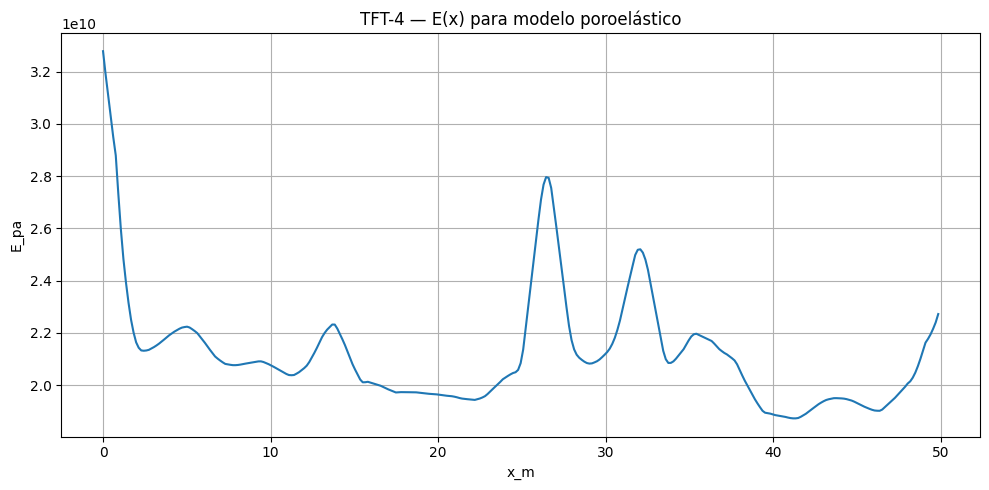

,DEPTH,x_m,E_pa
0,"2,350.136400",0.000000,"32,786,153,018.229519"
1,"2,350.288400",0.152000,"31,905,485,503.589760"
2,"2,350.440400",0.304000,"31,103,994,897.294281"
3,"2,350.592400",0.456000,"30,277,976,074.992485"
4,"2,350.744400",0.608000,"29,503,347,628.122078"


,DEPTH,x_m,E_pa
324,"2,399.384400",49.248000,"21,768,744,085.145435"
325,"2,399.536400",49.400000,"21,941,982,585.864567"
326,"2,399.688400",49.552000,"22,156,411,146.318531"
327,"2,399.840400",49.704000,"22,397,248,085.329918"
328,"2,399.992400",49.856000,"22,718,364,003.972057"


In [3]:
required_cols = ["DEPTH", "E_pa"]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Campos obrigatórios ausentes: {missing}")

work_df = df.copy()

if "physics_ready_valid" in work_df.columns:
    work_df = work_df[work_df["physics_ready_valid"].fillna(False).astype(bool)].copy()

work_df = work_df.dropna(subset=["DEPTH", "E_pa"]).sort_values("DEPTH").reset_index(drop=True)

if len(work_df) < 5:
    raise ValueError("Poucos pontos válidos para FEniCSx.")

work_df["x_m"] = work_df["DEPTH"] - work_df["DEPTH"].min()

L = float(work_df["x_m"].max())
N_data = len(work_df)

print(f"Pontos válidos: {N_data:,}")
print(f"Comprimento da zona L = {L:,.6f} m")

plt.figure(figsize=(10, 5))
plt.plot(work_df["x_m"], work_df["E_pa"], "-")
plt.title(f"{WELL_NAME} — E(x) para modelo poroelástico")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.grid(True)
plt.tight_layout()
plt.show()

display(work_df[["DEPTH", "x_m", "E_pa"]].head())
display(work_df[["DEPTH", "x_m", "E_pa"]].tail())

## Interpretação

Transformamos a profundidade real em coordenada local:

```text
x = DEPTH - DEPTH_MIN
```

Agora a zona do poço é o intervalo:

```text
0 <= x <= L
```

Neste domínio, a pressão será difundida e a rocha responderá mecanicamente.

# STEP 3 — Poroelastic Parameters

In [4]:
# ============================================================
# Parâmetros poroelásticos didáticos
# ============================================================

BIOT_ALPHA = 0.8

# Armazenamento específico simplificado [1/Pa]
STORAGE_S = 1.0e-9

# Permeabilidade efetiva [m²]
PERMEABILITY_K = 1.0e-14

# Viscosidade dinâmica do fluido [Pa.s]
FLUID_MU = 1.0e-3

# Difusividade hidráulica simplificada
HYDRAULIC_DIFFUSIVITY = PERMEABILITY_K / (FLUID_MU * STORAGE_S)

# Pressões [Pa]
P_INITIAL = 30.0e6
P_TOP = 25.0e6
P_BOTTOM = 30.0e6

# Tempo
TOTAL_TIME_SECONDS = 24 * 3600
N_TIME_STEPS = 24
DT = TOTAL_TIME_SECONDS / N_TIME_STEPS

params_df = pd.DataFrame([{
    "BIOT_ALPHA": BIOT_ALPHA,
    "STORAGE_S_1_PA": STORAGE_S,
    "PERMEABILITY_K_M2": PERMEABILITY_K,
    "FLUID_MU_PA_S": FLUID_MU,
    "HYDRAULIC_DIFFUSIVITY_M2_S": HYDRAULIC_DIFFUSIVITY,
    "P_INITIAL_PA": P_INITIAL,
    "P_TOP_PA": P_TOP,
    "P_BOTTOM_PA": P_BOTTOM,
    "TOTAL_TIME_SECONDS": TOTAL_TIME_SECONDS,
    "N_TIME_STEPS": N_TIME_STEPS,
    "DT_SECONDS": DT,
}])

display(params_df)

display(Markdown(f'''
## Interpretação dos parâmetros

### Cenário físico

- Pressão inicial: **{P_INITIAL/1e6:.1f} MPa**
- Pressão no topo após drawdown: **{P_TOP/1e6:.1f} MPa**
- Pressão na base: **{P_BOTTOM/1e6:.1f} MPa**

Estamos simulando uma queda de pressão no topo da zona.

### Difusividade hidráulica

```text
D = k / (mu*S) = {HYDRAULIC_DIFFUSIVITY:.2e} m²/s
```

Ela controla a velocidade com que a pressão se propaga.
'''))

,BIOT_ALPHA,STORAGE_S_1_PA,PERMEABILITY_K_M2,FLUID_MU_PA_S,HYDRAULIC_DIFFUSIVITY_M2_S,P_INITIAL_PA,P_TOP_PA,P_BOTTOM_PA,TOTAL_TIME_SECONDS,N_TIME_STEPS,DT_SECONDS
0,0.800000,0.000000,0.000000,0.001000,0.010000,"30,000,000.000000","25,000,000.000000","30,000,000.000000",86400,24,"3,600.000000"



## Interpretação dos parâmetros

### Cenário físico

- Pressão inicial: **30.0 MPa**
- Pressão no topo após drawdown: **25.0 MPa**
- Pressão na base: **30.0 MPa**

Estamos simulando uma queda de pressão no topo da zona.

### Difusividade hidráulica

```text
D = k / (mu*S) = 1.00e-02 m²/s
```

Ela controla a velocidade com que a pressão se propaga.


# STEP 4 — Create 1D Mesh and Function Space

In [5]:
N_CELLS = max(10, N_data - 1)

domain = mesh.create_interval(
    MPI.COMM_WORLD,
    N_CELLS,
    [0.0, L],
)

V = fem.functionspace(domain, ("Lagrange", 1))

print(f"Número de células: {N_CELLS}")
print(f"Número global de DOFs: {V.dofmap.index_map.size_global}")
print(f"Comprimento L: {L:,.6f} m")

Número de células: 328
Número global de DOFs: 329
Comprimento L: 49.856000 m


## Interpretação

Criamos a malha 1D e o espaço funcional para a pressão.

Usamos elementos lineares `P1`.

# STEP 5 — Interpolate E(x) into FEniCSx

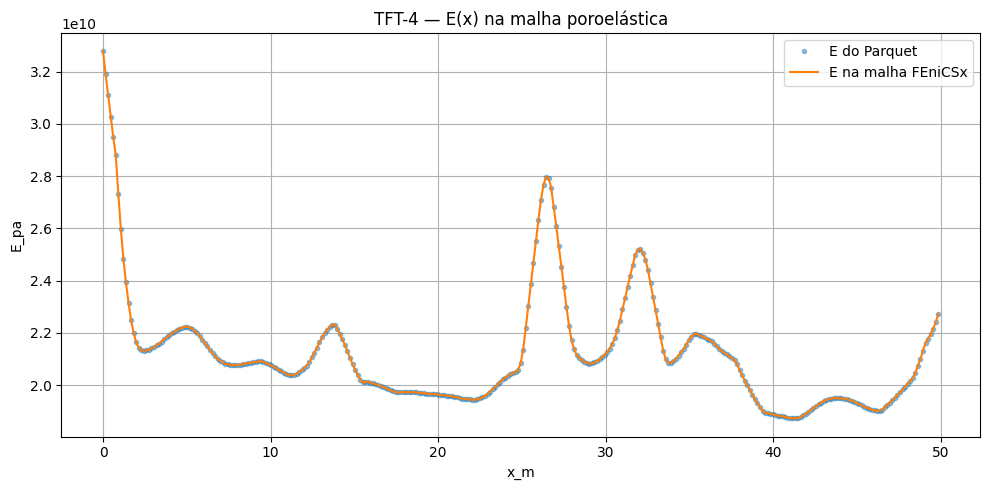

,x_m,E_pa
0,0.000000,"32,786,153,018.229519"
1,0.152000,"31,905,485,503.589760"
2,0.304000,"31,103,994,897.294281"
3,0.456000,"30,277,976,074.992485"
4,0.608000,"29,503,347,628.122078"


,x_m,E_pa
324,49.248000,"21,768,744,085.145435"
325,49.400000,"21,941,982,585.864567"
326,49.552000,"22,156,411,146.318531"
327,49.704000,"22,397,248,085.329918"
328,49.856000,"22,718,364,003.972057"


In [6]:
x_data = work_df["x_m"].to_numpy(dtype=float)
E_data = work_df["E_pa"].to_numpy(dtype=float)

E_fem = fem.Function(V)
E_fem.name = "E_pa"

def E_interpolator(x):
    return np.interp(x[0], x_data, E_data)

E_fem.interpolate(E_interpolator)


def function_to_safe_dataframe(V, function, value_name: str) -> pd.DataFrame:
    coords = V.tabulate_dof_coordinates()
    x_coords = coords[:, 0] if coords.ndim == 2 else coords.reshape(-1)
    values = function.x.array.real.copy()
    n = min(len(x_coords), len(values))

    out = (
        pd.DataFrame({"x_m": x_coords[:n], value_name: values[:n]})
        .sort_values("x_m")
        .reset_index(drop=True)
    )

    # Remove duplicações eventuais por layout local/ghosts
    out = out.groupby("x_m", as_index=False).agg({value_name: "mean"})
    return out.sort_values("x_m").reset_index(drop=True)


e_df = function_to_safe_dataframe(V, E_fem, "E_pa")

plt.figure(figsize=(10, 5))
plt.plot(x_data, E_data, ".", alpha=0.45, label="E do Parquet")
plt.plot(e_df["x_m"], e_df["E_pa"], "-", label="E na malha FEniCSx")
plt.title(f"{WELL_NAME} — E(x) na malha poroelástica")
plt.xlabel("x_m")
plt.ylabel("E_pa")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display(e_df.head())
display(e_df.tail())

## Interpretação

O módulo de Young virou uma função associada à malha.

Ele será usado para estimar a deformação poroelástica causada pela queda de pressão.

# STEP 6 — Pressure Diffusion Equation

A pressão será resolvida por difusão:

```text
S ∂p/∂t - ∂/∂x( (k/mu) ∂p/∂x ) = 0
```

Com Euler implícito:

```text
S (pⁿ⁺¹ - pⁿ)/dt - ∂/∂x( (k/mu) ∂pⁿ⁺¹/∂x ) = 0
```

Forma fraca compatível com kernel complexo:

```text
∫ S pⁿ⁺¹ conj(q) dx + dt ∫ (k/mu) inner(grad(pⁿ⁺¹), grad(q)) dx
=
∫ S pⁿ conj(q) dx
```

In [7]:
p = ufl.TrialFunction(V)
q = ufl.TestFunction(V)

dx = ufl.dx(domain)

S_const = fem.Constant(domain, PETSc.ScalarType(STORAGE_S))
mobility_const = fem.Constant(domain, PETSc.ScalarType(PERMEABILITY_K / FLUID_MU))
dt_const = fem.Constant(domain, PETSc.ScalarType(DT))

p_old = fem.Function(V)
p_old.name = "p_old"
p_old.x.array[:] = PETSc.ScalarType(P_INITIAL)

# Forma fraca corrigida para o kernel DOLFINx complex
a_p = (
    S_const * p * ufl.conj(q) * dx
    + dt_const
    * mobility_const
    * ufl.inner(ufl.grad(p), ufl.grad(q))
    * dx
)

L_p = S_const * p_old * ufl.conj(q) * dx

display(Markdown('''
## Interpretação

A equação de pressão está montada.

Como estamos usando o kernel `DOLFINx complex`, a função teste é conjugada com `ufl.conj(q)`.

O termo de gradiente usa `ufl.inner(ufl.grad(p), ufl.grad(q))`.
'''))


## Interpretação

A equação de pressão está montada.

Como estamos usando o kernel `DOLFINx complex`, a função teste é conjugada com `ufl.conj(q)`.

O termo de gradiente usa `ufl.inner(ufl.grad(p), ufl.grad(q))`.


# STEP 7 — Pressure Boundary Conditions

In [8]:
def top_boundary(x):
    return np.isclose(x[0], 0.0)

def bottom_boundary(x):
    return np.isclose(x[0], L)

top_dofs = fem.locate_dofs_geometrical(V, top_boundary)
bottom_dofs = fem.locate_dofs_geometrical(V, bottom_boundary)

bc_top_p = fem.dirichletbc(fem.Constant(domain, PETSc.ScalarType(P_TOP)), top_dofs, V)
bc_bottom_p = fem.dirichletbc(fem.Constant(domain, PETSc.ScalarType(P_BOTTOM)), bottom_dofs, V)

pressure_bcs = [bc_top_p, bc_bottom_p]

print("Top pressure DOFs:", top_dofs)
print("Bottom pressure DOFs:", bottom_dofs)

Top pressure DOFs: [0]
Bottom pressure DOFs: [328]


## Interpretação

Impomos:

```text
p(0,t) = P_TOP
p(L,t) = P_BOTTOM
```

Isso cria um gradiente de pressão na zona.

# STEP 8 — Time Stepping: Solve Pressure Diffusion

,x_m,p_pa,time_s,step
0,0.000000,"30,000,000.000000",0.000000,0
1,0.152000,"30,000,000.000000",0.000000,0
2,0.304000,"30,000,000.000000",0.000000,0
3,0.456000,"30,000,000.000000",0.000000,0
4,0.608000,"30,000,000.000000",0.000000,0


,x_m,p_pa,time_s,step
2298,49.248000,"29,943,959.112644","86,400.000000",24
2299,49.400000,"29,957,969.730083","86,400.000000",24
2300,49.552000,"29,971,980.008447","86,400.000000",24
2301,49.704000,"29,985,990.060743","86,400.000000",24
2302,49.856000,"30,000,000.000000","86,400.000000",24


Colunas: ['x_m', 'p_pa', 'time_s', 'step']


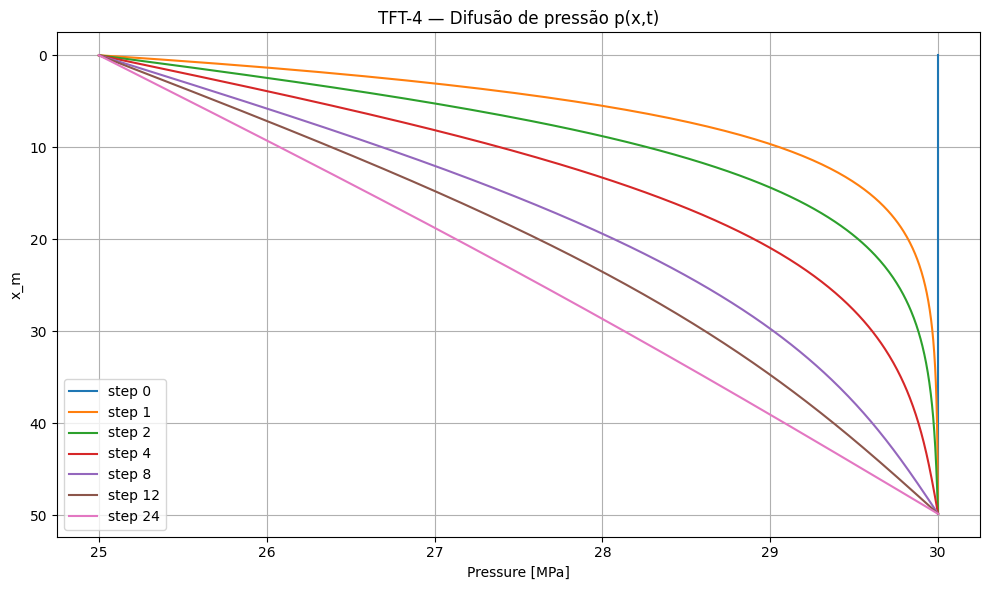

In [9]:
pressure_problem = LinearProblem(
    a_p,
    L_p,
    bcs=pressure_bcs,
    petsc_options_prefix="pressure_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
    },
    jit_options={
        "cache_dir": str(JIT_CACHE_DIR),
        "timeout": 120,
    },
)

time_snapshots = []

selected_steps = sorted(set([0, 1, 2, 4, 8, 12, N_TIME_STEPS]))

# Estado inicial
p_initial_df = function_to_safe_dataframe(V, p_old, "p_pa")
p_initial_df["time_s"] = 0.0
p_initial_df["step"] = 0
time_snapshots.append(p_initial_df)

for step in range(1, N_TIME_STEPS + 1):
    p_new = pressure_problem.solve()
    p_new.name = "pressure_p"

    # Atualiza o campo antigo para o próximo passo
    p_old.x.array[:] = p_new.x.array[:]

    if step in selected_steps:
        snap = function_to_safe_dataframe(V, p_new, "p_pa")
        snap["time_s"] = float(step * DT)
        snap["step"] = int(step)
        time_snapshots.append(snap)

pressure_history_df = pd.concat(time_snapshots, ignore_index=True)

# Blindagem final
if "step" not in pressure_history_df.columns:
    raise ValueError("A coluna step não foi criada no pressure_history_df.")

if "time_s" not in pressure_history_df.columns:
    pressure_history_df["time_s"] = pressure_history_df["step"] * DT

pressure_history_df = pressure_history_df.sort_values(["step", "x_m"]).reset_index(drop=True)

display(pressure_history_df.head())
display(pressure_history_df.tail())
print("Colunas:", pressure_history_df.columns.tolist())

plt.figure(figsize=(10, 6))
for step, group in pressure_history_df.groupby("step"):
    plt.plot(group["p_pa"] / 1e6, group["x_m"], label=f"step {step}")

plt.gca().invert_yaxis()
plt.title(f"{WELL_NAME} — Difusão de pressão p(x,t)")
plt.xlabel("Pressure [MPa]")
plt.ylabel("x_m")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Interpretação

A pressão foi resolvida no tempo com FEniCSx.

O topo está com pressão reduzida, simulando drawdown.

A base permanece na pressão inicial.

A curva mostra como a perturbação de pressão se distribui dentro da zona.

# STEP 9 — Mechanical Response from Pressure Change

In [10]:
# Copia limpa para evitar herança de estados antigos
pressure_for_mech_df = pressure_history_df.copy()

required_pressure_cols = {"x_m", "p_pa", "step", "time_s"}
missing_pressure_cols = required_pressure_cols - set(pressure_for_mech_df.columns)
if missing_pressure_cols:
    raise ValueError(f"Colunas ausentes em pressure_history_df: {missing_pressure_cols}")

pressure_for_mech_df = pressure_for_mech_df.sort_values(["step", "x_m"]).reset_index(drop=True)

# Interpola E nos pontos de pressão
pressure_for_mech_df["E_pa"] = np.interp(
    pressure_for_mech_df["x_m"],
    e_df["x_m"],
    e_df["E_pa"],
)

# Queda de pressão em relação ao estado inicial
pressure_for_mech_df["delta_p_pa"] = P_INITIAL - pressure_for_mech_df["p_pa"]

# Resposta poroelástica didática
pressure_for_mech_df["epsilon_poro"] = (
    BIOT_ALPHA * pressure_for_mech_df["delta_p_pa"] / pressure_for_mech_df["E_pa"]
)

def integrate_displacement_from_strain(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values("x_m").copy()
    x = g["x_m"].to_numpy(dtype=float)
    eps = g["epsilon_poro"].to_numpy(dtype=float)

    u = np.zeros_like(x)
    u[-1] = 0.0

    for i in range(len(x) - 2, -1, -1):
        dx_i = x[i + 1] - x[i]
        eps_avg = 0.5 * (eps[i + 1] + eps[i])
        u[i] = u[i + 1] - eps_avg * dx_i

    g["u_poro_m"] = u
    g["sigma_effective_pa"] = g["E_pa"] * g["epsilon_poro"]
    return g

poro_history_df = (
    pressure_for_mech_df
    .groupby("step", group_keys=False)
    .apply(integrate_displacement_from_strain)
    .reset_index(drop=True)
)

# Blindagem obrigatória
if "step" not in poro_history_df.columns:
    raise ValueError("A coluna step não existe em poro_history_df após o groupby/apply.")

if "time_s" not in poro_history_df.columns:
    poro_history_df["time_s"] = poro_history_df["step"] * DT

poro_history_df = poro_history_df.sort_values(["step", "x_m"]).reset_index(drop=True)

display(poro_history_df.head())
display(poro_history_df.tail())
print("Colunas:", poro_history_df.columns.tolist())

last_step = int(poro_history_df["step"].max())
last_df = poro_history_df[poro_history_df["step"] == last_step].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

axes[0].plot(last_df["p_pa"] / 1e6, last_df["x_m"])
axes[0].set_title("p final [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].plot(last_df["epsilon_poro"], last_df["x_m"])
axes[1].set_title("epsilon_poro final")
axes[1].set_xlabel("epsilon")

axes[2].plot(last_df["u_poro_m"], last_df["x_m"])
axes[2].set_title("u_poro final")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
fig.suptitle(f"{WELL_NAME} — Resposta poroelástica no tempo final", y=1.02)
plt.tight_layout()
plt.show()

ValueError: A coluna step não existe em poro_history_df após o groupby/apply.

## Interpretação

Agora a queda de pressão começou a gerar deformação.

Usamos:

```text
epsilon_poro = alpha * delta_p / E
```

Então:

- maior queda de pressão gera maior deformação;
- menor módulo de Young gera maior deformação;
- a deformação acumulada gera deslocamento.

# STEP 10 — Time Evolution Plots

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharey=True)

for step, group in poro_history_df.groupby("step"):
    axes[0].plot(group["p_pa"] / 1e6, group["x_m"], label=f"{step}")
    axes[1].plot(group["epsilon_poro"], group["x_m"], label=f"{step}")
    axes[2].plot(group["u_poro_m"], group["x_m"], label=f"{step}")

axes[0].set_title("p(x,t) [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].set_title("epsilon_poro(x,t)")
axes[1].set_xlabel("epsilon")

axes[2].set_title("u_poro(x,t)")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)
    ax.legend(title="step")

axes[0].invert_yaxis()
axes[0].set_ylabel("x_m")
fig.suptitle(f"{WELL_NAME} — Evolução poroelástica temporal", y=1.02)
plt.tight_layout()
plt.show()

## Interpretação

Agora vemos a evolução temporal de:

```text
pressão
deformação
deslocamento
```

Isto é o início da compactação por depleção.

# STEP 11 — Convert x Back to Real Depth

In [ ]:
depth_min = float(work_df["DEPTH"].min())

poro_history_df["DEPTH"] = poro_history_df["x_m"] + depth_min
poro_history_df["WELL"] = WELL_NAME

last_depth_df = poro_history_df[poro_history_df["step"] == poro_history_df["step"].max()].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharey=True)

axes[0].plot(last_depth_df["p_pa"] / 1e6, last_depth_df["DEPTH"])
axes[0].set_title("p final [MPa]")
axes[0].set_xlabel("Pressure [MPa]")

axes[1].plot(last_depth_df["epsilon_poro"], last_depth_df["DEPTH"])
axes[1].set_title("epsilon_poro final")
axes[1].set_xlabel("epsilon")

axes[2].plot(last_depth_df["u_poro_m"], last_depth_df["DEPTH"])
axes[2].set_title("u_poro final")
axes[2].set_xlabel("u [m]")

for ax in axes:
    ax.grid(True)

axes[0].invert_yaxis()
axes[0].set_ylabel("DEPTH")
fig.suptitle(f"{WELL_NAME} — Resultado poroelástico em profundidade real", y=1.02)
plt.tight_layout()
plt.show()

display(last_depth_df.head())
display(last_depth_df.tail())

## Interpretação

Agora a resposta poroelástica voltou para a profundidade real do poço.

Você consegue perguntar:

```text
em que profundidade a pressão caiu mais?
em que profundidade a deformação aumentou?
em que profundidade a compactação acumulada ficou mais forte?
```

# STEP 12 — Summary Metrics

In [ ]:
summary_rows = []

for step, group in poro_history_df.groupby("step"):
    group_sorted = group.sort_values("x_m")
    summary_rows.append({
        "WELL": WELL_NAME,
        "STEP": int(step),
        "TIME_S": float(group_sorted["time_s"].iloc[0]),
        "TIME_H": float(group_sorted["time_s"].iloc[0] / 3600),
        "P_MIN_MPA": float(group_sorted["p_pa"].min() / 1e6),
        "P_MAX_MPA": float(group_sorted["p_pa"].max() / 1e6),
        "DELTA_P_MAX_MPA": float(group_sorted["delta_p_pa"].max() / 1e6),
        "EPSILON_MAX": float(group_sorted["epsilon_poro"].max()),
        "EPSILON_MEAN": float(group_sorted["epsilon_poro"].mean()),
        "U_TOP_M": float(group_sorted["u_poro_m"].iloc[0]),
        "U_BASE_M": float(group_sorted["u_poro_m"].iloc[-1]),
        "SIGMA_EFFECTIVE_MAX_MPA": float(group_sorted["sigma_effective_pa"].max() / 1e6),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("STEP").reset_index(drop=True)
display(summary_df)

plt.figure(figsize=(10, 5))
plt.plot(summary_df["TIME_H"], summary_df["DELTA_P_MAX_MPA"], "o-", label="Max drawdown [MPa]")
plt.plot(summary_df["TIME_H"], summary_df["EPSILON_MAX"] * 1e6, "o-", label="Max epsilon [microstrain]")
plt.xlabel("Time [h]")
plt.title(f"{WELL_NAME} — Evolução resumida")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretação

A tabela resume o comportamento temporal.

Ela mostra:

- drawdown máximo;
- deformação máxima;
- deslocamento no topo;
- tensão efetiva máxima.

Esse resumo será muito útil para comparar cenários.

# STEP 13 — Export Poroelasticity Results

In [ ]:
safe_well_name = WELL_NAME.replace("/", "_").replace(" ", "_")

simulation_path = DATA_SIMULATION_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_history.parquet"
summary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_summary.csv"
params_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_parameters.csv"

poro_history_df.to_parquet(simulation_path, index=False)
summary_df.to_csv(summary_path, index=False)
params_df.to_csv(params_path, index=False)

column_dictionary = pd.DataFrame({
    "COLUMN": poro_history_df.columns,
    "DTYPE": [str(poro_history_df[c].dtype) for c in poro_history_df.columns],
    "NON_NULL_COUNT": [poro_history_df[c].notna().sum() for c in poro_history_df.columns],
    "NULL_COUNT": [poro_history_df[c].isna().sum() for c in poro_history_df.columns],
    "FILL_RATE": [poro_history_df[c].notna().mean() for c in poro_history_df.columns],
})

column_dictionary_path = REPORT_DIR / f"{safe_well_name}_fenicsx_poroelasticity_1d_column_dictionary.csv"
column_dictionary.to_csv(column_dictionary_path, index=False)

print("SIMULAÇÃO POROELÁSTICA EXPORTADA COM SUCESSO!")
print(f"Histórico parquet: {simulation_path}")
print(f"Resumo: {summary_path}")
print(f"Parâmetros: {params_path}")
print(f"Dicionário: {column_dictionary_path}")

display(summary_df)
display(column_dictionary)

# STEP 14 — Final Interpretation

Este notebook iniciou a poroelasticidade no projeto.

## O que fizemos

```text
physics-ready parquet
↓
malha 1D
↓
difusão de pressão com FEniCSx
↓
drawdown no topo
↓
pressão p(x,t)
↓
deformação poroelástica aproximada
↓
deslocamento u(x,t)
↓
tensão efetiva
```

## O que este modelo já responde

- Como a pressão se dissipa em uma zona do reservatório?
- Onde o drawdown é maior?
- Como a queda de pressão gera deformação?
- Quais regiões são mais sensíveis mecanicamente?
- Como a resposta evolui no tempo?

## Próximo avanço técnico

Este modelo é semiacoplado.

O próximo passo científico será:

```text
05B.1 — Fully Coupled Biot 1D with FEniCSx
```

onde `u(x,t)` e `p(x,t)` serão resolvidos juntos.